### Expected runtime of this notebook is <10 minutes

In [1]:
import json, os, pickle
import numpy as np
from tqdm.notebook import tqdm
import pandas as pd

import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import qiskit.circuit.random
import torch, random
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn as nn

import numpy as np
import json, os, pickle
from tqdm import tqdm
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from qiskit import QuantumCircuit

import sys
sys.path.append('../tutorials/')
from mlp import encode_data, encode_data_v2_ecr

# Load data (from hardware experiment)

In [2]:
def check_f(f, f_ext, step_indices):
    return f.endswith(f_ext) and any([f"step_%02d"%step_index in f for step_index in step_indices])

def load_circuits(data_dir, step_indices, f_ext='.pk'):
    Js = []
    circuits = []
    data_files = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if check_f(f, f_ext, step_indices)])
    for data_file in tqdm(data_files, leave=True):
        for entry in pickle.load(open(data_file, 'rb')):
            Js.append(entry['J'])
            circuits.append(entry['circuit'])
    return circuits, Js

In [3]:
circuits, Js = load_circuits('../tutorials/data/ising_zne_hardware/100q_brisbane/', list(range(1, 11)))

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:36<00:00, 13.70it/s]


In [4]:
for step_index in [1]:
    with open('../tutorials/zne_mitigated/twirl_100q_brisbane/step%02d.json'%step_index, 'r') as file:
        loaded = json.load(file)
    noise_factor_1 = np.array(loaded['noise_factor_1'])
    noise_factor_3 = np.array(loaded['noise_factor_3'])

for step_index in tqdm([2, 3, 4, 5, 6, 7, 8, 9, 10]):
    with open('../tutorials/zne_mitigated/twirl_100q_brisbane/step%02d.json'%step_index, 'r') as file:
        loaded = json.load(file)
    noise_factor_1 = np.concatenate([noise_factor_1, loaded['noise_factor_1']])
    noise_factor_3 = np.concatenate([noise_factor_3, loaded['noise_factor_3']])

noise_factor_1_tw_avg = noise_factor_1.reshape(noise_factor_1.shape[0], 5, 5).mean(axis=-1)
noise_factor_3_tw_avg = noise_factor_3.reshape(noise_factor_3.shape[0], 5, 5).mean(axis=-1)

slope = (noise_factor_3_tw_avg - noise_factor_1_tw_avg) / 2
zne_mitigated_vals = (noise_factor_1_tw_avg - slope).tolist()
noisy_vals = noise_factor_1_tw_avg.tolist()
len(zne_mitigated_vals)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 796.39it/s]


500

In [5]:
print(len(circuits), len(zne_mitigated_vals), len(noisy_vals))

500 500 500


# Preprocessing

In [6]:
def count_gates_by_rotation_angle(circuit, bin_size):
    angles = []
    for instr, qargs, cargs in circuit.data:
        if instr.name in ['rx', 'ry', 'rz'] and len(qargs) == 1:
            angles += [float(instr.params[0])]
    bin_edges = np.arange(-2 * np.pi, 2 * np.pi + bin_size, bin_size)
    counts, _ = np.histogram(angles, bins=bin_edges)
    bin_labels = [f"{left:.2f} to {right:.2f}" for left, right in zip(bin_edges[:-1], bin_edges[1:])]
    angle_bins = {label: count for label, count in zip(bin_labels, counts)}
    return list(angle_bins.values())


def recursive_dict_loop(my_dict, parent_key=None, out=None, target_key1=None, target_key2=None):
    if out is None: out = []

    for key, val in my_dict.items():
        if isinstance(val, dict):
            recursive_dict_loop(val, key, out, target_key1, target_key2)
        else:
            if parent_key and target_key1 in str(parent_key) and key == target_key2:
                out += [val]
    return out or 0.


def encode_data_v2_ecr_CLIP_encoder(circuits, 
                                    ideal_exp_vals, 
                                    noisy_exp_vals, 
                                    obs_size, 
                                    tokenizer,
                                    text_model,
                                    device,
                                    max_len = 77,
                                    meas_bases=None, 
                                    two_q_gate='ecr'):
    
    if isinstance(noisy_exp_vals[0], list) and len(noisy_exp_vals[0]) == 1:
        noisy_exp_vals = [x[0] for x in noisy_exp_vals]

    if meas_bases is None:
        meas_bases = [[]]

    gates_set = [two_q_gate] + ['sx', 'x', 'id', 'rz']

    vec = []

    bin_size = 0.025 * np.pi
    num_angle_bins = int(np.ceil(4 * np.pi / bin_size))

    X = torch.zeros([len(circuits), 512 + len(vec) + len(gates_set) + num_angle_bins + obs_size + len(meas_bases[0])]) #512 for CLIP Embedding

    embedding_slice = slice(0,512)
    vec_slice = slice(512, 512+len(vec))
    gate_counts_slice = slice(512+len(vec), 512+len(vec)+len(gates_set))
    angle_bins_slice = slice(512+len(vec)+len(gates_set), 512+len(vec)+len(gates_set)+num_angle_bins)
    exp_val_slice = slice(512+len(vec)+len(gates_set)+num_angle_bins, 512+len(vec)+len(gates_set)+num_angle_bins+obs_size)
    meas_basis_slice = slice(512+len(vec)+len(gates_set)+num_angle_bins+obs_size, len(X[0]))

    # X[:, vec_slice] = vec[None, :]

    for i, circ in enumerate(tqdm(circuits)):
        circuit_qasm = circ.qasm()

        tokens = tokenizer(circuit_qasm, return_tensors="pt", truncation=False, padding=False)
        input_ids = tokens["input_ids"][0]  # remove batch dimension
        
        chunks = [input_ids[i:i + max_len] for i in range(0, len(input_ids), max_len)]
        
        # Encode each chunk and collect pooled outputs
        embeddings = []
        
        for chunk in chunks:
            chunk = chunk.unsqueeze(0).to(device)
            with torch.no_grad():
                output = text_model(input_ids=chunk)
                pooled = output.pooler_output  # shape: (1, hidden_dim)
            embeddings.append(pooled.cpu())  # keep CPU to save GPU memory
        
        # Combine embeddings (mean pooling)
        final_embedding = torch.mean(torch.stack(embeddings), dim=0)

        
        X[i, embedding_slice] = torch.tensor(final_embedding)

    
    for i, circ in enumerate(circuits):
        gate_counts_all = circ.count_ops()
        X[i, gate_counts_slice] = torch.tensor(
            [gate_counts_all.get(key, 0) for key in gates_set]
        ) * 0.01  # put it in the same order of magnitude as the expectation values

    for i, circ in enumerate(circuits):
        gate_counts = count_gates_by_rotation_angle(circ, bin_size)
        X[i, angle_bins_slice] = torch.tensor(gate_counts) * 0.01  # put it in the same order of magnitude as the expectation values

        if obs_size > 1: assert len(noisy_exp_vals[i]) == obs_size
        elif obs_size == 1: assert isinstance(noisy_exp_vals[i], float)

        X[i, exp_val_slice] = torch.tensor(noisy_exp_vals[i])

    if meas_bases != [[]]:
        assert len(meas_bases) == len(circuits)
        for i, basis in enumerate(meas_bases):
            X[i, meas_basis_slice] = torch.tensor(basis)

    y = torch.tensor(ideal_exp_vals, dtype=torch.float32)

    return X, y

In [32]:
num_circ_per_step = 50
k = train_test_split = 10
train_circuits = []
train_zne_vals = []
train_noisy_vals = []
test_circuits = []
test_zne_vals = []
test_noisy_vals = []
test_Js = []
for start_each_step in list(range(len(circuits))[::num_circ_per_step]):
    train_circuits += circuits[start_each_step:start_each_step+k]
    train_zne_vals += zne_mitigated_vals[start_each_step:start_each_step+k]
    train_noisy_vals += noisy_vals[start_each_step:start_each_step+k]
    test_circuits += circuits[start_each_step+k:start_each_step+num_circ_per_step]
    test_zne_vals += zne_mitigated_vals[start_each_step+k:start_each_step+num_circ_per_step]
    test_noisy_vals += noisy_vals[start_each_step+k:start_each_step+num_circ_per_step]
    test_Js += Js[start_each_step+k:start_each_step+num_circ_per_step]

In [33]:
print(len(train_circuits), len(train_zne_vals), len(train_noisy_vals))
print(len(test_circuits), len(test_zne_vals), len(test_noisy_vals))

100 100 100
400 400 400


### Adding the random circuits

In [31]:
from importlib import reload
import RandomCircuitGenerator
reload(RandomCircuitGenerator)
from RandomCircuitGenerator import generate_random_circuits


random_circuits, random_expect_ideal_per_qubit, random_expect_noise_per_qubit = generate_random_circuits(
    num_qubits=5, 
    num_circuits=1000, 
    circuit_depth=10
)


In [34]:
train_circuits.extend(random_circuits)
train_zne_vals.extend(random_expect_ideal_per_qubit)
train_noisy_vals.extend(random_expect_noise_per_qubit)

In [35]:
print(len(train_circuits), len(train_zne_vals), len(train_noisy_vals))
print(len(test_circuits), len(test_zne_vals), len(test_noisy_vals))

1100 1100 1100
400 400 400


In [36]:
normal_X_train, normal_y_train = encode_data_v2_ecr(train_circuits, train_zne_vals, train_noisy_vals, obs_size=5)
normal_X_test, normal_y_test = encode_data_v2_ecr(test_circuits, test_zne_vals, test_noisy_vals, obs_size=5)

In [ ]:
# CLIP Encoder
from transformers import CLIPTokenizer, CLIPTextModel
import torch
from tqdm import tqdm
import time

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load tokenizer and model
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
text_model = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
text_model.eval()

X_train, y_train = encode_data_v2_ecr_CLIP_encoder(train_circuits, 
                                                   train_zne_vals, 
                                                   train_noisy_vals, 
                                                   tokenizer=tokenizer,
                                                   text_model=text_model,
                                                   device=device,
                                                   obs_size=5)
torch.save(X_train, 'CLIP_Average_X_train.pt')
torch.save(y_train, 'CLIP_Average_y_train.pt')

X_test, y_test = encode_data_v2_ecr_CLIP_encoder(test_circuits, 
                                                 test_zne_vals, 
                                                 test_noisy_vals, 
                                                 tokenizer=tokenizer,
                                                 text_model=text_model,
                                                 device=device,
                                                 obs_size=5)

torch.save(X_test, 'CLIP_Average_X_test.pt')
torch.save(y_test, 'CLIP_Average_y_test.pt')

In [37]:
# torch.save(X_train, 'CLIP_Average_X_train.pt')
# torch.save(y_train, 'CLIP_Average_y_train.pt')
# torch.save(X_test, 'CLIP_Average_X_test.pt')
# torch.save(y_test, 'CLIP_Average_y_test.pt')

X_train = torch.load("CLIP_Average_X_train.pt")
y_train = torch.load("CLIP_Average_y_train.pt")
X_test = torch.load("CLIP_Average_X_test.pt")
y_test = torch.load("CLIP_Average_y_test.pt")

print(X_train.shape)

torch.Size([100, 682])


In [38]:
normal_X_train[0][-5:]

tensor([ 0.0232, -0.0192, -0.0258,  0.0370,  0.0283])

In [39]:
X_train[0][-5:]

tensor([ 0.0232, -0.0192, -0.0258,  0.0370,  0.0283])

In [40]:
BATCH_SIZE = 32
train_dataset = TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataset = TensorDataset(torch.Tensor(X_test), torch.Tensor(y_test))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE*1000, shuffle=False)

normal_train_dataset = TensorDataset(torch.Tensor(normal_X_train), torch.Tensor(normal_y_train))
normal_train_loader = DataLoader(normal_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
normal_test_dataset = TensorDataset(torch.Tensor(normal_X_test), torch.Tensor(normal_y_test))
normal_test_loader = DataLoader(normal_test_dataset, batch_size=BATCH_SIZE*1000, shuffle=False)

In [41]:
X_train = pd.DataFrame(X_train)
y_train = pd.DataFrame(y_train)
X_test = pd.DataFrame(X_test)
y_test = pd.DataFrame(y_test)

normal_X_train = pd.DataFrame(normal_X_train)
normal_y_train = pd.DataFrame(normal_y_train)
normal_X_test = pd.DataFrame(normal_X_test)
normal_y_test = pd.DataFrame(normal_y_test)

# Training RF

### Other models can be done similarly

In [15]:
X_test.shape

(400, 682)

In [42]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
rfr_tree_list = []
for q in range(5):
    rfr = RandomForestRegressor(n_estimators=500)
    rfr.fit(X_train, y_train.iloc[:, q])
    rfr_tree_list.append(rfr)


normal_rfr_tree_list = []
for q in range(5):
    rfr = RandomForestRegressor(n_estimators=100)
    rfr.fit(normal_X_train, normal_y_train.iloc[:, q])
    normal_rfr_tree_list.append(rfr)

RMSE_noisy_0: 0.06622940680866209
RMSE_mitigated_0: 0.04726854261615126
RMSE_noisy_1: 0.06571337924238625
RMSE_mitigated_1: 0.04578470788111003
RMSE_noisy_2: 0.0654646813056526
RMSE_mitigated_2: 0.05001448454182471
RMSE_noisy_3: 0.06489176308232669
RMSE_mitigated_3: 0.053958038159527204
RMSE_noisy_4: 0.06681302970392002
RMSE_mitigated_4: 0.053599295924896664
RMSE_noisy: 0.0655765734696172
RMSE_mitigated: 0.04935451636583754


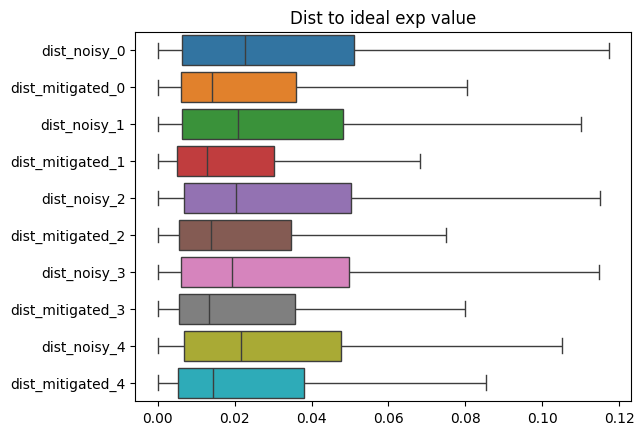

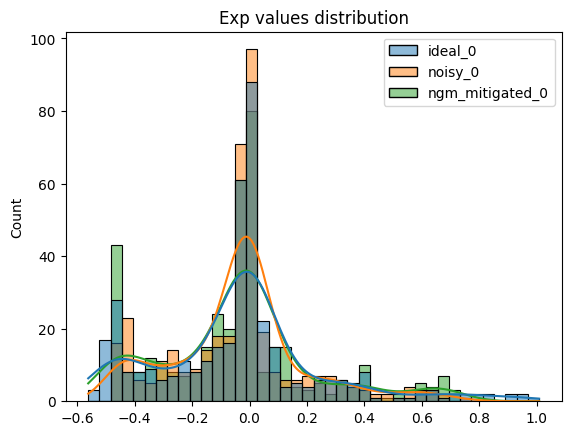

In [43]:
distances = []

num_spins = 5

for batch_X, batch_y in test_loader:
    out = []
    for q, model in enumerate(rfr_tree_list):
        out.append(model.predict(batch_X[:, :]))
    out = np.array(out).transpose()

    for ideal, noisy, ngm_mitigated in zip(
        batch_y.tolist(),
        batch_X[:, -5:].tolist(),
        out.tolist()
    ):
        for q in range(5):
            ideal_q = ideal[q]
            noisy_q = noisy[q]
            ngm_mitigated_q = ngm_mitigated[q]
            distances.append({
                f"ideal_{q}": ideal_q,
                f"noisy_{q}": noisy_q,
                f"ngm_mitigated_{q}": ngm_mitigated_q,
                f"dist_noisy_{q}": np.abs(ideal_q - noisy_q),
                f"dist_mitigated_{q}": np.abs(ideal_q - ngm_mitigated_q),
                f"dist_sq_noisy_{q}": np.square(ideal_q - noisy_q),
                f"dist_sq_mitigated_{q}": np.square(ideal_q - ngm_mitigated_q),
            })

plt.style.use({'figure.facecolor':'white'})

df = pd.DataFrame(distances)

for q in range(5):
    print(f'RMSE_noisy_{q}:', np.sqrt(df[f"dist_sq_noisy_{q}"].mean()))
    print(f'RMSE_mitigated_{q}:', np.sqrt(df[f"dist_sq_mitigated_{q}"].mean()))

print(f'RMSE_noisy:', np.sqrt(np.mean([df[f"dist_sq_noisy_{q}"].mean() for q in range(4)])))
print(f'RMSE_mitigated:', np.sqrt(np.mean([df[f"dist_sq_mitigated_{q}"].mean() for q in range(4)])))

sns.boxplot(data=df[["dist_noisy_0", "dist_mitigated_0", "dist_noisy_1", "dist_mitigated_1", "dist_noisy_2", "dist_mitigated_2", "dist_noisy_3", "dist_mitigated_3", "dist_noisy_4", "dist_mitigated_4"]], orient="h", showfliers = False)
plt.title("Dist to ideal exp value")
plt.show()

sns.histplot([df['ideal_0'], df['noisy_0'], df["ngm_mitigated_0"]], kde=True, bins=40)
plt.title("Exp values distribution")
plt.show()

In [44]:
def evaluate_loader(test_loader, model_list, label: str):
    results = []

    for batch_X, batch_y in test_loader:
        predictions = []
        for q, model in enumerate(model_list):
            predictions.append(model.predict(batch_X[:, :]))
        predictions = np.array(predictions).transpose()

        for ideal, noisy_or_normal, mitigated in zip(
            batch_y.tolist(),
            batch_X[:, -5:].tolist(),
            predictions.tolist()
        ):
            for q in range(5):
                ideal_q = ideal[q]
                noisy_q = noisy_or_normal[q]
                mitigated_q = mitigated[q]

                results.append({
                    "source": label,
                    f"ideal_{q}": ideal_q,
                    f"input_{q}": noisy_q,
                    f"mitigated_{q}": mitigated_q,
                    f"dist_{q}": np.abs(ideal_q - noisy_q),
                    f"dist_mitigated_{q}": np.abs(ideal_q - mitigated_q),
                    f"dist_sq_{q}": np.square(ideal_q - noisy_q),
                    f"dist_sq_mitigated_{q}": np.square(ideal_q - mitigated_q),
                })
    return results


In [45]:
ngm_results = evaluate_loader(test_loader, rfr_tree_list, label="CLIP")
normal_results = evaluate_loader(normal_test_loader, normal_rfr_tree_list, label="Normal")
all_results = ngm_results + normal_results

df = pd.DataFrame(all_results)


In [46]:
for q in range(5):
    for label in ["Normal", "CLIP"]:
        subset = df[df["source"] == label]
        rmse = np.sqrt(subset[f"dist_sq_{q}"].mean())
        rmse_mitigated = np.sqrt(subset[f"dist_sq_mitigated_{q}"].mean())
        print(f"[{label}] RMSE_input_{q}: {rmse:.4f}, RMSE_mitigated_{q}: {rmse_mitigated:.4f}")

print("------ Overall RMSEs ------")
for label in ["Normal", "CLIP"]:
    subset = df[df["source"] == label]
    rmse = np.sqrt(np.mean([subset[f"dist_sq_{q}"].mean() for q in range(5)]))
    rmse_mitigated = np.sqrt(np.mean([subset[f"dist_sq_mitigated_{q}"].mean() for q in range(5)]))
    print(f"[{label}] RMSE_input: {rmse:.4f}, RMSE_mitigated: {rmse_mitigated:.4f}")


[Normal] RMSE_input_0: 0.0662, RMSE_mitigated_0: 0.0378
[CLIP] RMSE_input_0: 0.0662, RMSE_mitigated_0: 0.0473
[Normal] RMSE_input_1: 0.0657, RMSE_mitigated_1: 0.0322
[CLIP] RMSE_input_1: 0.0657, RMSE_mitigated_1: 0.0458
[Normal] RMSE_input_2: 0.0655, RMSE_mitigated_2: 0.0320
[CLIP] RMSE_input_2: 0.0655, RMSE_mitigated_2: 0.0500
[Normal] RMSE_input_3: 0.0649, RMSE_mitigated_3: 0.0379
[CLIP] RMSE_input_3: 0.0649, RMSE_mitigated_3: 0.0540
[Normal] RMSE_input_4: 0.0668, RMSE_mitigated_4: 0.0341
[CLIP] RMSE_input_4: 0.0668, RMSE_mitigated_4: 0.0536
------ Overall RMSEs ------
[Normal] RMSE_input: 0.0658, RMSE_mitigated: 0.0349
[CLIP] RMSE_input: 0.0658, RMSE_mitigated: 0.0502


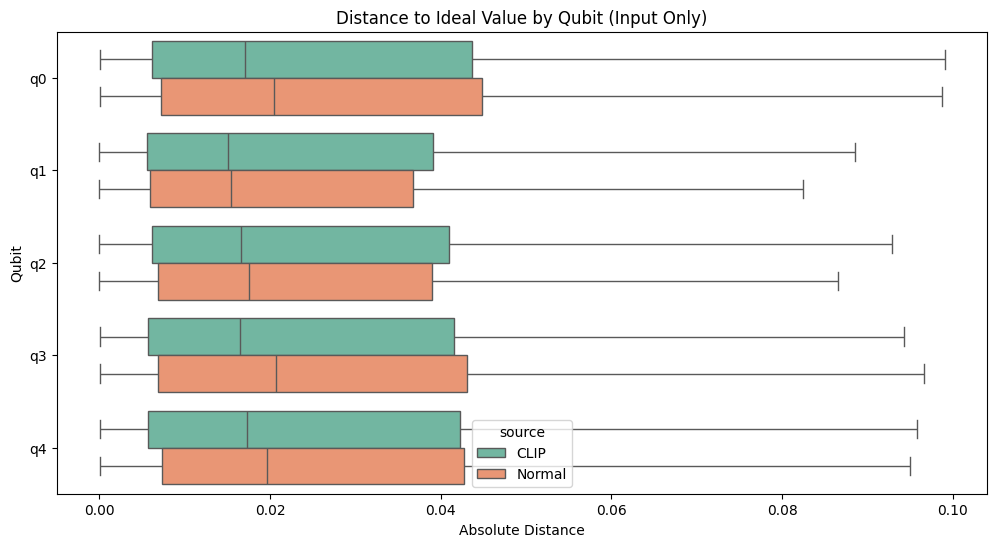

In [47]:
melted = pd.DataFrame()

for q in range(5):
    for metric in ["dist", "dist_mitigated"]:
        temp = df[[f"{metric}_{q}", "source"]].copy()
        temp = temp.rename(columns={f"{metric}_{q}": "value"})
        temp["qubit"] = f"q{q}"
        temp["type"] = "input" if "dist_" == metric else "mitigated"
        melted = pd.concat([melted, temp], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted, x="value", y="qubit", hue="source", palette="Set2", showfliers=False)
plt.title("Distance to Ideal Value by Qubit (Input Only)")
plt.xlabel("Absolute Distance")
plt.ylabel("Qubit")
plt.show()


# Pre-Training Transformer

In [29]:
import numpy as np
from sklearn.model_selection import train_test_split
# torch.save(X_train, 'CLIP_Average_X_train.pt')
# torch.save(y_train, 'CLIP_Average_y_train.pt')
# torch.save(X_test, 'CLIP_Average_X_test.pt')
# torch.save(y_test, 'CLIP_Average_y_test.pt')

X_train = torch.load("CLIP_Average_X_train.pt")
y_train = torch.load("CLIP_Average_y_train.pt")
X_test = torch.load("CLIP_Average_X_test.pt")
y_test = torch.load("CLIP_Average_y_test.pt")

def generate_synthetic_data_with_labels(X_real, y_real, total_samples=10000, test_ratio=0.2, noise_std_factor=1.0, random_seed=42):
    """
    Generate synthetic data and labels using Gaussian noise and label resampling.

    Parameters:
    - X_real (np.ndarray): Real training features, shape (n_samples, n_features)
    - y_real (np.ndarray): Real training labels, shape (n_samples,) or (n_samples, n_outputs)
    - total_samples (int): Total number of synthetic samples to generate
    - test_ratio (float): Fraction of samples to reserve as test
    - noise_std_factor (float): Standard deviation multiplier for noise
    - random_seed (int): Seed for reproducibility

    Returns:
    - X_synth_train, X_synth_test, y_synth_train, y_synth_test
    """
    np.random.seed(random_seed)
    X_real = X_real.numpy()
    y_real = y_real.numpy()

    # Step 1: Generate synthetic features
    mean = np.mean(X_real, axis=0)
    std = np.std(X_real, axis=0)

    noise = np.random.randn(total_samples, X_real.shape[1]) * std * noise_std_factor
    X_synthetic = mean + noise

    # Step 2: Sample synthetic labels with replacement
    y_synthetic = np.random.choice(y_real.flatten(), size=total_samples, replace=True)
    if y_real.ndim == 2:  # multi-output case
        y_synthetic = np.array([y_real[np.random.randint(0, len(y_real))] for _ in range(total_samples)])

    # Step 3: Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_synthetic, y_synthetic, test_size=test_ratio, random_state=random_seed
    )

    return X_train, X_test, y_train, y_test






Shapes:
  X_synth_train: (40000, 682)
  y_synth_train: (40000,)
  X_synth_test: (10000, 682)
  y_synth_test: (10000,)


In [30]:
from importlib import reload
import simple_transformer
reload(simple_transformer)
from simple_transformer import SimpleTransformerEstimator

In [33]:

for qubit_index in range(5):

    X_synth_train, X_synth_test, y_synth_train, y_synth_test = generate_synthetic_data_with_labels(
        X_real=X_train,
        y_real=y_train[:,qubit_index],
        total_samples=50000,
        test_ratio=0.2,
        noise_std_factor=1.0
    )
    
    print("Shapes:")
    print("  X_synth_train:", X_synth_train.shape)
    print("  y_synth_train:", y_synth_train.shape)
    print("  X_synth_test:", X_synth_test.shape)
    print("  y_synth_test:", y_synth_test.shape)
    
    # Optionally save
    # np.save("synthetic_train.npy", synth_train)
    # np.save("synthetic_test.npy", synth_test)
    
    
    number_of_epochs = 5
    number_heads = 4
    model_depth = 64
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    model = SimpleTransformerEstimator(n_epochs=number_of_epochs, 
                                           nhead=number_heads,
                                           d_model=model_depth,
                                           lr=0.001,
                                           verbose=True,
                                           device=device,
                                           lr_scheduler='step',
                                           step_size=1,
                                           seq_len=682,
                                           batch_size=1000)
        
    model.fit(X_synth_train, y_synth_train)
    
    model.save(f"pretrained_q{qubit_index}.pt")



Shapes:
  X_synth_train: (40000, 682)
  y_synth_train: (40000,)
  X_synth_test: (10000, 682)
  y_synth_test: (10000,)
cuda


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:09<00:00,  4.03it/s]


Epoch 1/5 | loss=0.1376 | lr=5.00e-04


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:09<00:00,  4.00it/s]


Epoch 2/5 | loss=0.1123 | lr=2.50e-04


...

Epoch 3/5 | loss=0.1125 | lr=1.25e-04


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:10<00:00,  3.84it/s]


Epoch 4/5 | loss=0.1126 | lr=6.25e-05


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:10<00:00,  3.86it/s]

Epoch 5/5 | loss=0.1125 | lr=3.13e-05
Saved weights to 'pretrained_q4.pt'.


Saved weights to 'pretrained_q1.pt'.


In [67]:
pred_x_val = model.predict(X_synth_test)
np.mean((pred_x_val - y_synth_test)**2)

0.113362074

# Transformer Model

In [48]:
from simple_transformer import SimpleTransformerEstimator

In [50]:
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = pd.DataFrame(X_train)
y_train = pd.DataFrame(y_train)
X_test = pd.DataFrame(X_test)
y_test = pd.DataFrame(y_test)

normal_X_train = pd.DataFrame(normal_X_train)
normal_y_train = pd.DataFrame(normal_y_train)
normal_X_test = pd.DataFrame(normal_X_test)
normal_y_test = pd.DataFrame(normal_y_test)

# model = SimpleTransformerEstimator(n_epochs=100, 
#                                    verbose=True,
#                                    device=device,
#                                    seq_len=682)
# model.fit(X_train, y_train)

number_of_epochs = 1000
number_heads = 4
model_depth = 64

# trained_transformer_list_with_CLIP = []
# for q in range(5):
#     model = SimpleTransformerEstimator(n_epochs=number_of_epochs, 
#                                        nhead=number_heads,
#                                        d_model=model_depth,
#                                        lr=0.001,
#                                        verbose=False,
#                                        device=device,
#                                        lr_scheduler='step',
#                                        step_size=300,
#                                        pretrained_path=f'pretrained_q0.pt',
#                                        seq_len=682)
    
#     model.fit(X_train, y_train.iloc[:, q])
#     trained_transformer_list_with_CLIP.append(model)
#     print(f"Done with {q}")


trained_transformer_list = []
for q in range(5):
    model = SimpleTransformerEstimator(n_epochs=number_of_epochs, 
                                       nhead=number_heads,
                                       d_model=model_depth,
                                       lr=0.001,
                                       verbose=True,
                                       device=device,
                                       lr_scheduler='step',
                                       step_size=300,
                                       batch_size=128,
                                       seq_len=170)
    
    model.fit(normal_X_train, normal_y_train.iloc[:, q])
    trained_transformer_list.append(model)
    print(f"Done with {q}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 201.02it/s]


Epoch 1/1000 | loss=0.2090 | lr=1.00e-03


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 223.21it/s]


Epoch 101/1000 | loss=0.0132 | lr=1.00e-03


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 223.49it/s]


...

Epoch 801/1000 | loss=0.0114 | lr=2.50e-04


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 223.73it/s]


Epoch 901/1000 | loss=0.0114 | lr=1.25e-04


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 223.21it/s]

Epoch 1000/1000 | loss=0.0113 | lr=1.25e-04
Done with 4


In [51]:
trans_clip_results = evaluate_loader(test_loader, trained_transformer_list_with_CLIP, label="CLIP+Transformer")
normal_results = evaluate_loader(normal_test_loader, normal_rfr_tree_list, label="RandomForests")
trans_results = evaluate_loader(normal_test_loader, trained_transformer_list, label="Transformer")
all_results = trans_clip_results + normal_results + trans_results

df = pd.DataFrame(all_results)


In [52]:
for q in range(5):
    for label in ["RandomForests", "Transformer", "CLIP+Transformer"]:
        subset = df[df["source"] == label]
        rmse = np.sqrt(subset[f"dist_sq_{q}"].mean())
        rmse_mitigated = np.sqrt(subset[f"dist_sq_mitigated_{q}"].mean())
        print(f"[{label}] RMSE_input_{q}: {rmse:.4f}, RMSE_mitigated_{q}: {rmse_mitigated:.4f}")

print("------ Overall RMSEs ------")
for label in ["RandomForests", "Transformer", "CLIP+Transformer"]:
    subset = df[df["source"] == label]
    rmse = np.sqrt(np.mean([subset[f"dist_sq_{q}"].mean() for q in range(5)]))
    rmse_mitigated = np.sqrt(np.mean([subset[f"dist_sq_mitigated_{q}"].mean() for q in range(5)]))
    print(f"[{label}] RMSE_input: {rmse:.4f}, RMSE_mitigated: {rmse_mitigated:.4f}")


[RandomForests] RMSE_input_0: 0.0662, RMSE_mitigated_0: 0.0378
[Transformer] RMSE_input_0: 0.0662, RMSE_mitigated_0: 0.0457
[CLIP+Transformer] RMSE_input_0: 0.0662, RMSE_mitigated_0: 0.2865
[RandomForests] RMSE_input_1: 0.0657, RMSE_mitigated_1: 0.0322
[Transformer] RMSE_input_1: 0.0657, RMSE_mitigated_1: 0.0362
[CLIP+Transformer] RMSE_input_1: 0.0657, RMSE_mitigated_1: 0.0343
[RandomForests] RMSE_input_2: 0.0655, RMSE_mitigated_2: 0.0320
[Transformer] RMSE_input_2: 0.0655, RMSE_mitigated_2: 0.0543
[CLIP+Transformer] RMSE_input_2: 0.0655, RMSE_mitigated_2: 0.0219
[RandomForests] RMSE_input_3: 0.0649, RMSE_mitigated_3: 0.0379
[Transformer] RMSE_input_3: 0.0649, RMSE_mitigated_3: 0.0295
[CLIP+Transformer] RMSE_input_3: 0.0649, RMSE_mitigated_3: 0.0337
[RandomForests] RMSE_input_4: 0.0668, RMSE_mitigated_4: 0.0341
[Transformer] RMSE_input_4: 0.0668, RMSE_mitigated_4: 0.0456
[CLIP+Transformer] RMSE_input_4: 0.0668, RMSE_mitigated_4: 0.0355
------ Overall RMSEs ------
[RandomForests] RMSE_i

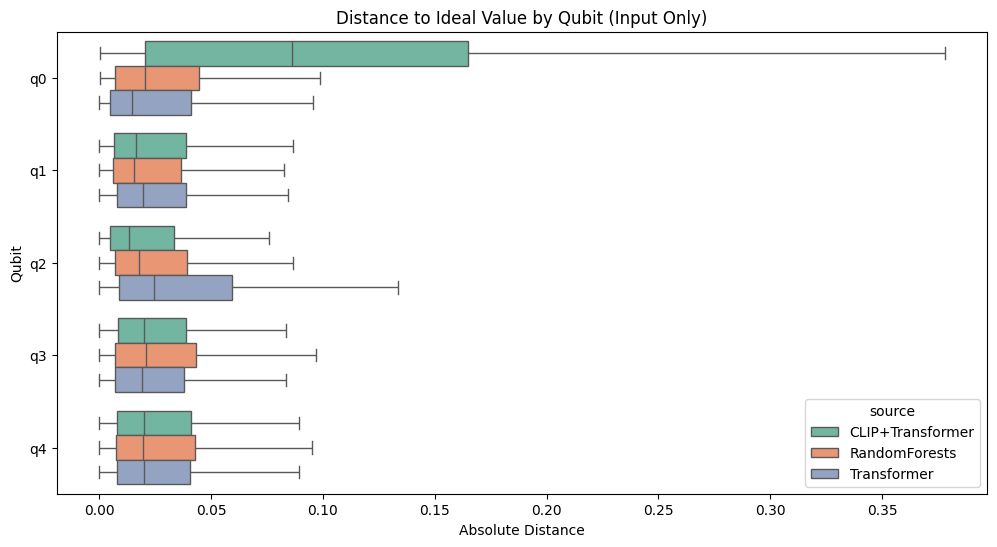

In [53]:
melted = pd.DataFrame()

for q in range(5):
    for metric in ["dist", "dist_mitigated"]:
        temp = df[[f"{metric}_{q}", "source"]].copy()
        temp = temp.rename(columns={f"{metric}_{q}": "value"})
        temp["qubit"] = f"q{q}"
        temp["type"] = "input" if "dist_" == metric else "mitigated"
        melted = pd.concat([melted, temp], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted, x="value", y="qubit", hue="source", palette="Set2", showfliers=False)
plt.title("Distance to Ideal Value by Qubit (Input Only)")
plt.xlabel("Absolute Distance")
plt.ylabel("Qubit")
# plt.savefig("pretraining-1.png")
plt.show()

# Get mimicry results on individual testing circuit

In [ ]:
to_df = []
steps = np.repeat(np.arange(1, 11), num_circ_per_step-train_test_split)

models = []
models.append((rfr_tree_list, 'rfr_list'))

for i, (circ_trans, noisy_exp_val, zne_mitigated, step, J) in tqdm(enumerate(zip(test_circuits, test_noisy_vals, test_zne_vals, steps, test_Js)), total=len(test_noisy_vals)):
    row = dict()
    row['noisy'] = noisy_exp_val
    row['zne_mitigated'] = zne_mitigated
    row['step'] = step
    row['J'] = J

    X, _ = encode_data_v2_ecr([circ_trans], [zne_mitigated], [noisy_exp_val], obs_size=5)

    for j, (model, name) in enumerate(models):
        if name == 'mlp':
            row[name] = model(X).tolist()[0]
        elif name == 'gnn':
            row[name] = model(entry.noisy_0,
                            entry.observable,
                            entry.circuit_depth,
                            entry.x,
                            entry.edge_index,
                            entry.batch).tolist()[0]
        elif name in ['ols_full', 'rfr_full']:
            row[name] = model.predict(X).tolist()[0]
        elif name in ['ols', 'rfr']:
            row[name] = model.predict(X[:, -5:]).tolist()[0]
        elif name in ['rfr_list']:
            row[name] = []
            for q, m in enumerate(model):
                row[name].append(m.predict(X))
            row[name] = np.array(row[name]).transpose()[0]
        elif name in ['zne']:
            row[name] = zne_mitigated
        else:
            raise NotImplementedError

    to_df.append(row)

df = pd.DataFrame(to_df)

In [ ]:
for k in range(0, 40):
    new_df = pd.DataFrame(to_df).iloc[k::num_circ_per_step-train_test_split]

    import warnings
    warnings.filterwarnings('ignore')

    for col in new_df.columns:
        if col not in ['step']:
            new_df[f'mean_{col}'] = new_df[col].apply(np.mean)
            new_df[f'ste_{col}'] = new_df[col].apply(np.std) / np.sqrt(num_circ_per_step-train_test_split)

    plt.style.use({'figure.facecolor':'white'})
    plt.figure(figsize=(7, 5))
    steps = sorted(set(new_df.step))
    legend_labels = ['Unmitigated', 'ZNE', 'RF Mimicking ZNE']

    for i, col in enumerate(['mean_noisy', 'mean_zne_mitigated', 'mean_rfr_list']):
        plt.plot(steps, new_df[col], label=legend_labels[i], marker='o', color=f'C{i+1}')
        plt.fill_between(x=steps, y1=new_df[col]-new_df['ste_'+'_'.join(col.split('_')[1:])], y2=new_df[col]+new_df['ste_'+'_'.join(col.split('_')[1:])], alpha=0.2, color=f'C{i+1}')
    plt.title(f'{k}-th test sample with J={test_Js[k]}')
    plt.xlabel('Trotter Step')
    plt.ylabel(r'Mean')
    xmin, xmax = plt.gca().get_xlim()
    plt.xlim([xmin, xmax])
    plt.hlines(y=0, xmin=xmin, xmax=xmax, color='gray', linestyles='dashed')
    plt.legend()
    plt.grid(None)
    plt.show()